In [2]:
from archetype_style_analysis import *
from archetype_visualisation import *
from preprocessing import *

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# We use vgg19_bn instead of vgg19 since it is better
model = models.vgg19_bn(weights=models.VGG19_BN_Weights)
model = model.to(device)
model.eval()
return_nodes = {
    "features.2": "layer1",
    "features.5": "layer2",
    "features.9": "layer3",
    "features.12": "layer4",
    "features.16": "layer5",
}
feature_extractor = create_feature_extractor(model, return_nodes=return_nodes)

/home/mkhales-24/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
all_paths = glob("ArtemisArt/**/*.jpg")
paths = all_paths[::4]
print(f"Il y a {len(paths)} images dans le dataset")

Il y a 3639 images dans le dataset


In [5]:
# def imshow_filter(kernels, row, col):
#     print("-------------------------------------------------------------")
#     plt.figure(figsize=(10, 10))
#     for i in range(len(kernels)):
#         img = np.mean(kernels[i], axis=0)
#         img = img - img.min()
#         img = img / img.max()

#         plt.subplot(row, col, i + 1)
#         plt.imshow(img, cmap="gray")
#         plt.xticks([])
#         plt.yticks([])
#     plt.show()


# conv_layers = []
# for name, module in model.named_modules():
#     if type(module).__name__ == "Conv2d":
#         conv_layers.append(module)

# ### !!!! Attention, y'a vraiment beaucoup d'images qui sont générés donc vaut mieux
# ### sélectionner un layer en particulier !!!!

# for conv in conv_layers:
#     print(conv)
#     kernels = conv.weight.data.cpu().numpy()
#     print(kernels.shape)
#     rows = 8
#     imshow_filter(kernels, rows, kernels.shape[0] // rows)

In [6]:
# def visualize_feature_maps(image_path, extractor, layer_name="layer4", max_features=64):
#     print("-" * 60)
#     img = imread_safe(image_path)

#     preprocess_img = preprocessing_image(img)
#     tensor_img = preprocess_img.to(device)

#     with torch.no_grad():
#         features_dict = extractor(tensor_img)

#     f_map = features_dict[layer_name].squeeze(0).cpu().numpy()

#     print(f"Layer name : {layer_name}")

#     n_features = min(f_map.shape[0], max_features)
#     col = 8
#     row = (n_features + col - 1) // col

#     plt.figure(figsize=(15, 2 * row))

#     for i in range(n_features):
#         activation = f_map[i]

#         activation = activation - activation.min()
#         if activation.max() != 0:
#             activation = activation / activation.max()

#         plt.subplot(row, col, i + 1)
#         plt.imshow(activation, cmap="gray")
#         plt.xticks([])
#         plt.yticks([])

#     plt.tight_layout()
#     plt.show()
#     plt.close()


# img_path = paths[0]
# print(img_path)

# visualize_feature_maps(img_path, feature_extractor, layer_name="layer1")
# visualize_feature_maps(img_path, feature_extractor, layer_name="layer2")
# visualize_feature_maps(img_path, feature_extractor, layer_name="layer3")
# visualize_feature_maps(img_path, feature_extractor, layer_name="layer4")
# visualize_feature_maps(img_path, feature_extractor, layer_name="layer5")

In [7]:
n_archetype = 16
a = ArchetypeGenerator(n_archetype, paths, device, feature_extractor)
A, B, Z, ipca_mod = a.find_archetypes()

Starting transformation of the data...


  0%|          | 0/3639 [00:00<?, ?it/s]

100%|██████████| 3639/3639 [22:03<00:00,  2.75it/s] 


Starting IncrementalPCA fitting...


100%|██████████| 8/8 [11:41<00:00, 87.69s/it] 


Starting transformation of the data via IncrementalPCA...


100%|██████████| 8/8 [00:53<00:00,  6.74s/it]


shape of X : (3617, 512)
Starting archetype generation...


In [8]:
images_synthetisees = [
            synthetiser_archetype(
                Z_archetype=Z[i],
                pca_model=ipca_mod,
                extractor=feature_extractor,
                device=device,
                n_iteration=500,
            )
            for i in range(n_archetype)
]
for i in range(len(images_synthetisees)):
    plt.imshow(images_synthetisees[i])
    plt.axis("off")
    plt.title(f"L'essence de l'Archétype {i}")
    plt.savefig(f"archetype_{i}.png", bbox_inches="tight", dpi=300)
    print(f"Image sauvegardée sous le nom 'archetype_{i}.png' !")

    plt.close()

Début de la synthèse (500 itérations, image 224x224, lr=0.01, poids_style=1.0, poids_tv=0.1)...
  Itération 0000 | Style: 2.0462e-01 | TV: 6.6588e-01 | Total: 2.7121e-01
  Itération 0100 | Style: 1.2940e-02 | TV: 4.2083e-02 | Total: 1.7148e-02
  Itération 0200 | Style: 9.7726e-03 | TV: 2.2497e-02 | Total: 1.2022e-02
  Itération 0300 | Style: 5.5812e-03 | TV: 2.0879e-02 | Total: 7.6692e-03
  Itération 0400 | Style: 1.6474e-03 | TV: 1.9393e-02 | Total: 3.5867e-03
Début de la synthèse (500 itérations, image 224x224, lr=0.01, poids_style=1.0, poids_tv=0.1)...
  Itération 0000 | Style: 1.8310e-01 | TV: 6.6669e-01 | Total: 2.4977e-01
  Itération 0100 | Style: 1.1074e-02 | TV: 4.9961e-02 | Total: 1.6070e-02
  Itération 0200 | Style: 8.7957e-03 | TV: 3.0353e-02 | Total: 1.1831e-02
  Itération 0300 | Style: 6.1834e-03 | TV: 2.9669e-02 | Total: 9.1504e-03
  Itération 0400 | Style: 3.3317e-03 | TV: 2.8437e-02 | Total: 6.1754e-03
Début de la synthèse (500 itérations, image 224x224, lr=0.01, poids_

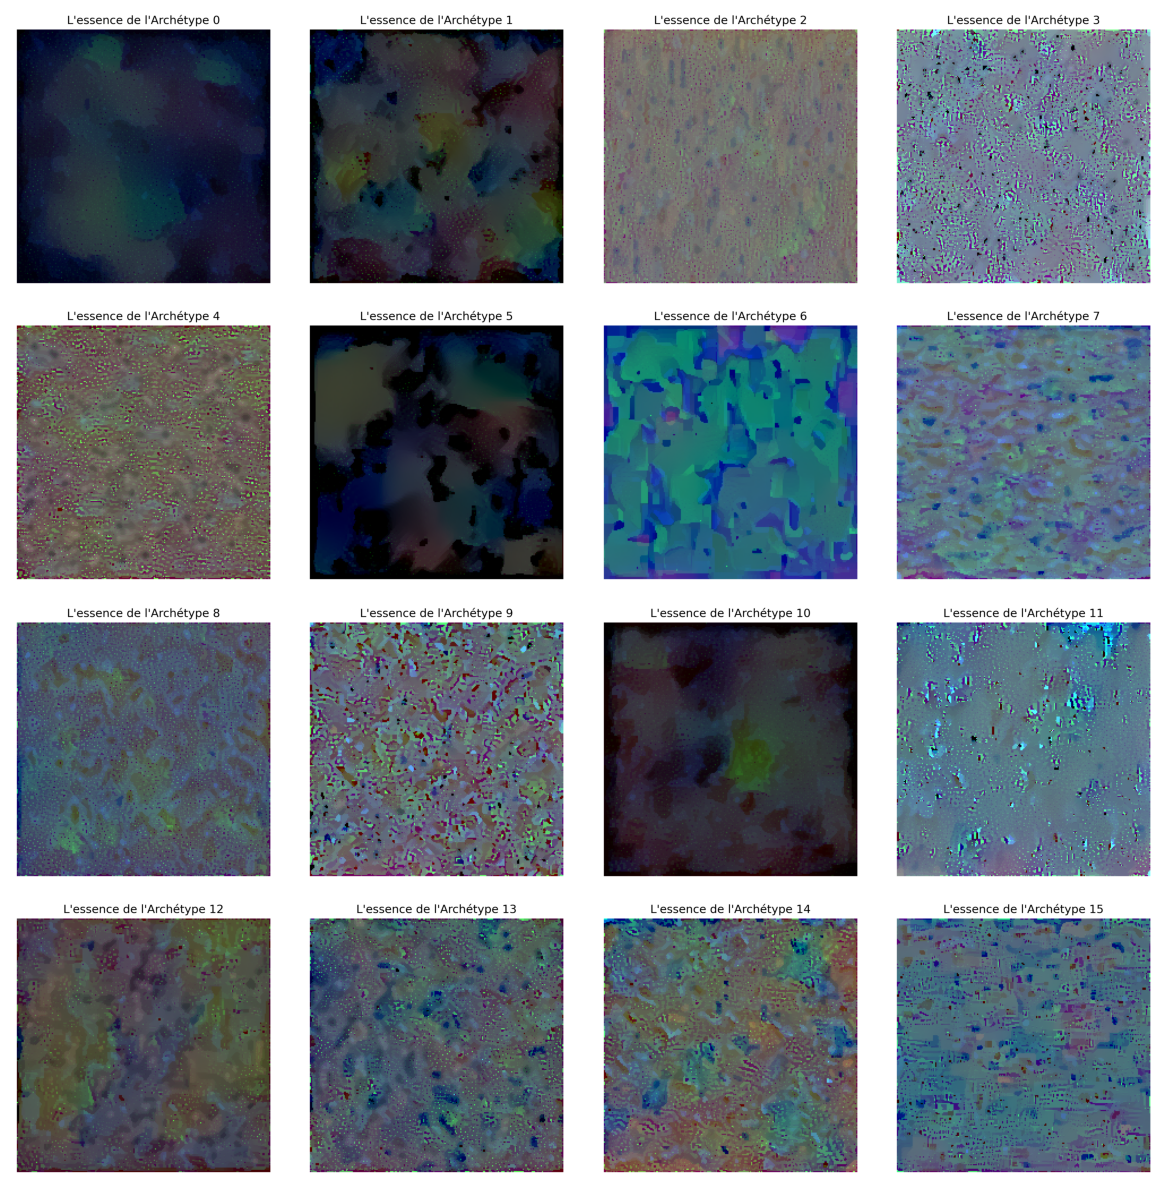

In [56]:
cols = 4
rows = 4

fig, axes = plt.subplots(rows, cols, figsize=(12, 12))

for i in range(16):
    img = imread_safe(f"archetype_{i}.png")
    ax = axes[i // cols, i % cols]   # ligne, colonne

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

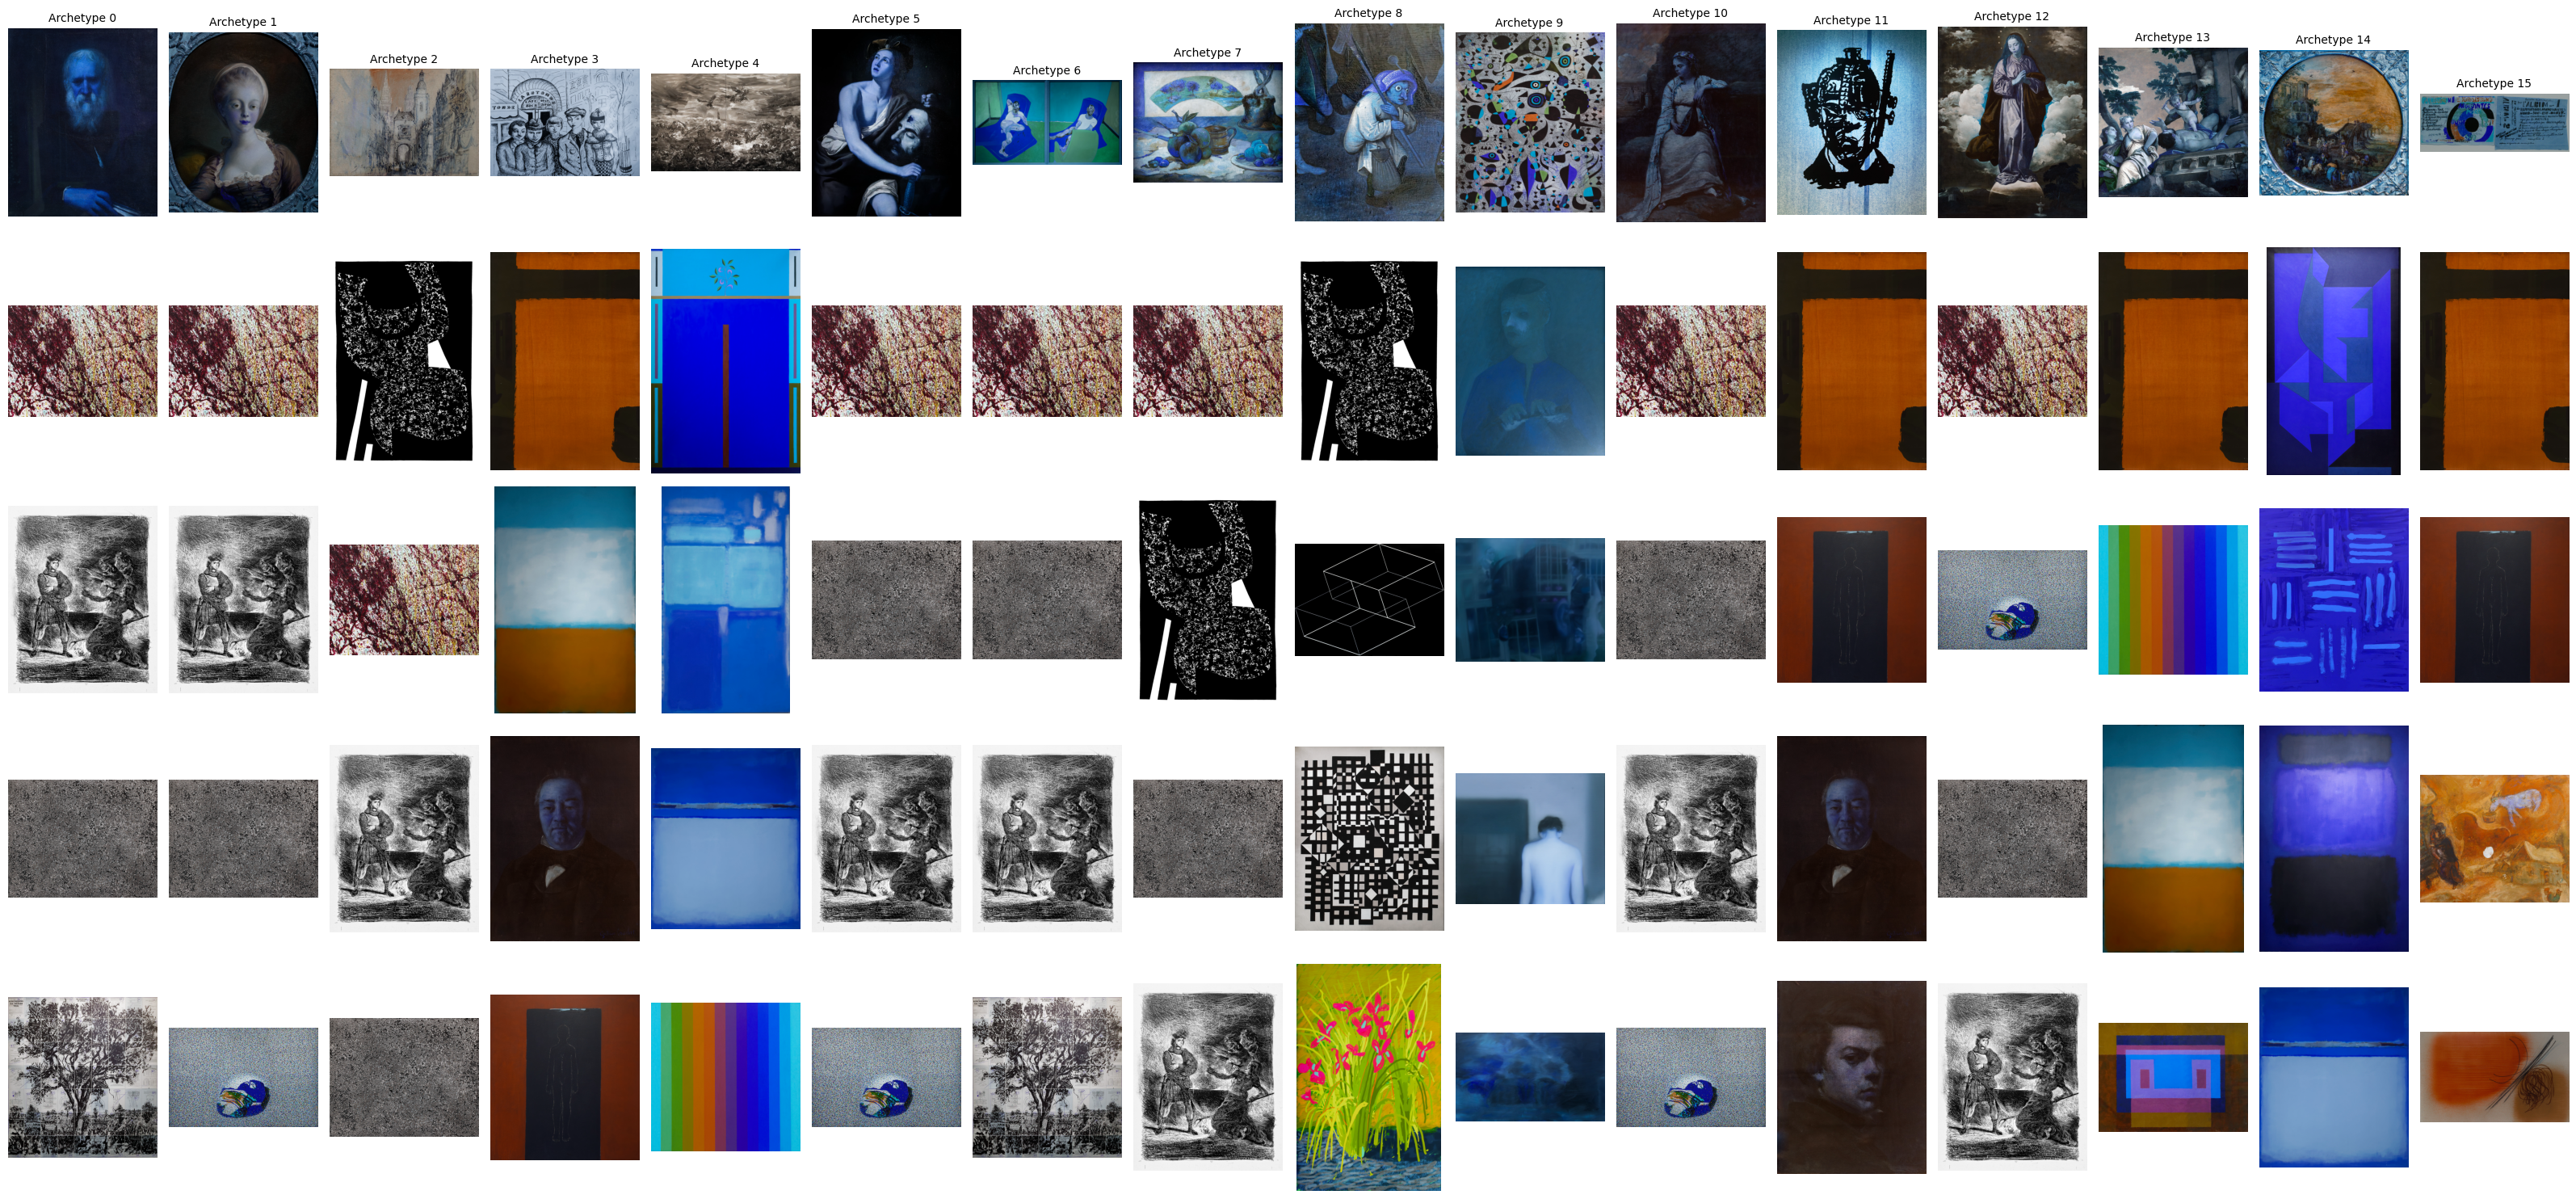

In [47]:
cols = n_archetype
rows = 5
fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 3*rows))
for i in range(n_archetype):
    L = a.getClosestPaintingsForArchetype(i, 5)
    for k in range(5):
        ax = axes[k,i]
        X_k = imread_safe(L[k])
        ax.imshow(X_k)
        ax.axis("off")
        if k == 0:
            ax.set_title(f"Archetype {i}", fontsize=10)
plt.tight_layout()
plt.show()
        

In [19]:
dict = {i: 0 for i in range(15)}
for i in range(n_archetype):
    L = a.getPaintingsFromArchetype(i)
    print(f"For archetype {i}: {L}")
    dict[i] = len(L)

For archetype 0: ['ArtemisArt/snyders - frans-snyders_1579/snyders_8.jpg'
 'ArtemisArt/granacci - francesco-granacci_1469/granacci_4.jpg'
 'ArtemisArt/van-dyck - antoon-van-dyck_1599/van-dyck_49.jpg'
 'ArtemisArt/gerard - francois-gerard-baron_1770/gerard_13.jpg'
 'ArtemisArt/de-la-tour - georges-de-la-tour_1640/de-la-tour_26.jpg'
 'ArtemisArt/van-dyck - antoon-van-dyck_1599/van-dyck_45.jpg'
 'ArtemisArt/corot - jean-baptiste-camille-corot_1796/corot_86.jpg'
 'ArtemisArt/decamps - alexandre-gabriel-decamps_1803/decamps_19.jpg'
 'ArtemisArt/sustermans - justus-sustermans_1597/sustermans_2.jpg'
 'ArtemisArt/del-sarto - andrea-d-agnolo-di-francesco-dit-del-sarto_1486/del-sarto_38.jpg'
 'ArtemisArt/henner - jean-jacques-henner_1829/henner_39.jpg'
 'ArtemisArt/titien - tiziano-vecellio_1488/titien_37.jpg'
 'ArtemisArt/gros - antoine-jean-gros-dit-baron-gros_1771/gros_9.jpg'
 'ArtemisArt/friant - emile-friant_1863/friant_20.jpg'
 'ArtemisArt/rigaud - hyacinthe-rigaud_1659/rigaud_11.jpg'
 'Ar

In [60]:
import csv
# FAIT PAR IA pour que ce soit plus rapide
path_to_archetype = {}

for i in range(n_archetype):
    L = a.getPaintingsFromArchetype(i)
    for p in L:
        path_to_archetype[p] = i

# 2. Exporter dans l'ordre de paths
with open("paths_archetypes.csv", "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["path", "archetype"])

    for p in paths:
        writer.writerow([p, path_to_archetype.get(p, -1)])
# FIN

{0: 220, 1: 233, 2: 228, 3: 220, 4: 263, 5: 224, 6: 219, 7: 227, 8: 215, 9: 230, 10: 241, 11: 211, 12: 210, 13: 247, 14: 216, 15: 213}


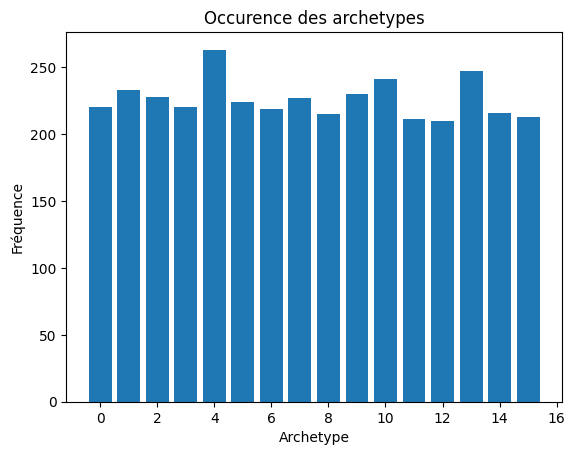

In [59]:
print(dict)

keys = list(dict.keys())
values = list(dict.values())

plt.bar(keys, values)
plt.xlabel("Archetype")
plt.ylabel("Fréquence")
plt.title("Occurence des archetypes")
plt.show()


9:[0, 1, 3, 21, 24, 22, 32, 79, 38]
9:[0, 2, 8, 19, 26, 24, 21, 86, 47]
9:[0, 2, 5, 22, 22, 22, 27, 86, 42]
9:[0, 4, 2, 23, 20, 19, 30, 83, 39]
9:[0, 3, 12, 20, 33, 18, 34, 102, 41]
9:[0, 1, 4, 32, 23, 15, 25, 78, 46]
9:[0, 5, 3, 25, 29, 19, 22, 78, 38]
9:[0, 2, 4, 26, 24, 19, 21, 101, 30]
9:[0, 1, 6, 16, 33, 20, 28, 81, 30]
9:[1, 0, 4, 20, 24, 20, 22, 89, 50]
9:[0, 6, 8, 32, 27, 19, 32, 75, 42]
9:[2, 1, 7, 22, 22, 16, 19, 87, 35]
9:[0, 2, 2, 17, 29, 21, 28, 75, 36]
9:[0, 3, 6, 20, 29, 21, 36, 87, 45]
9:[0, 2, 4, 22, 20, 28, 25, 82, 33]
9:[0, 1, 12, 16, 29, 21, 28, 59, 47]


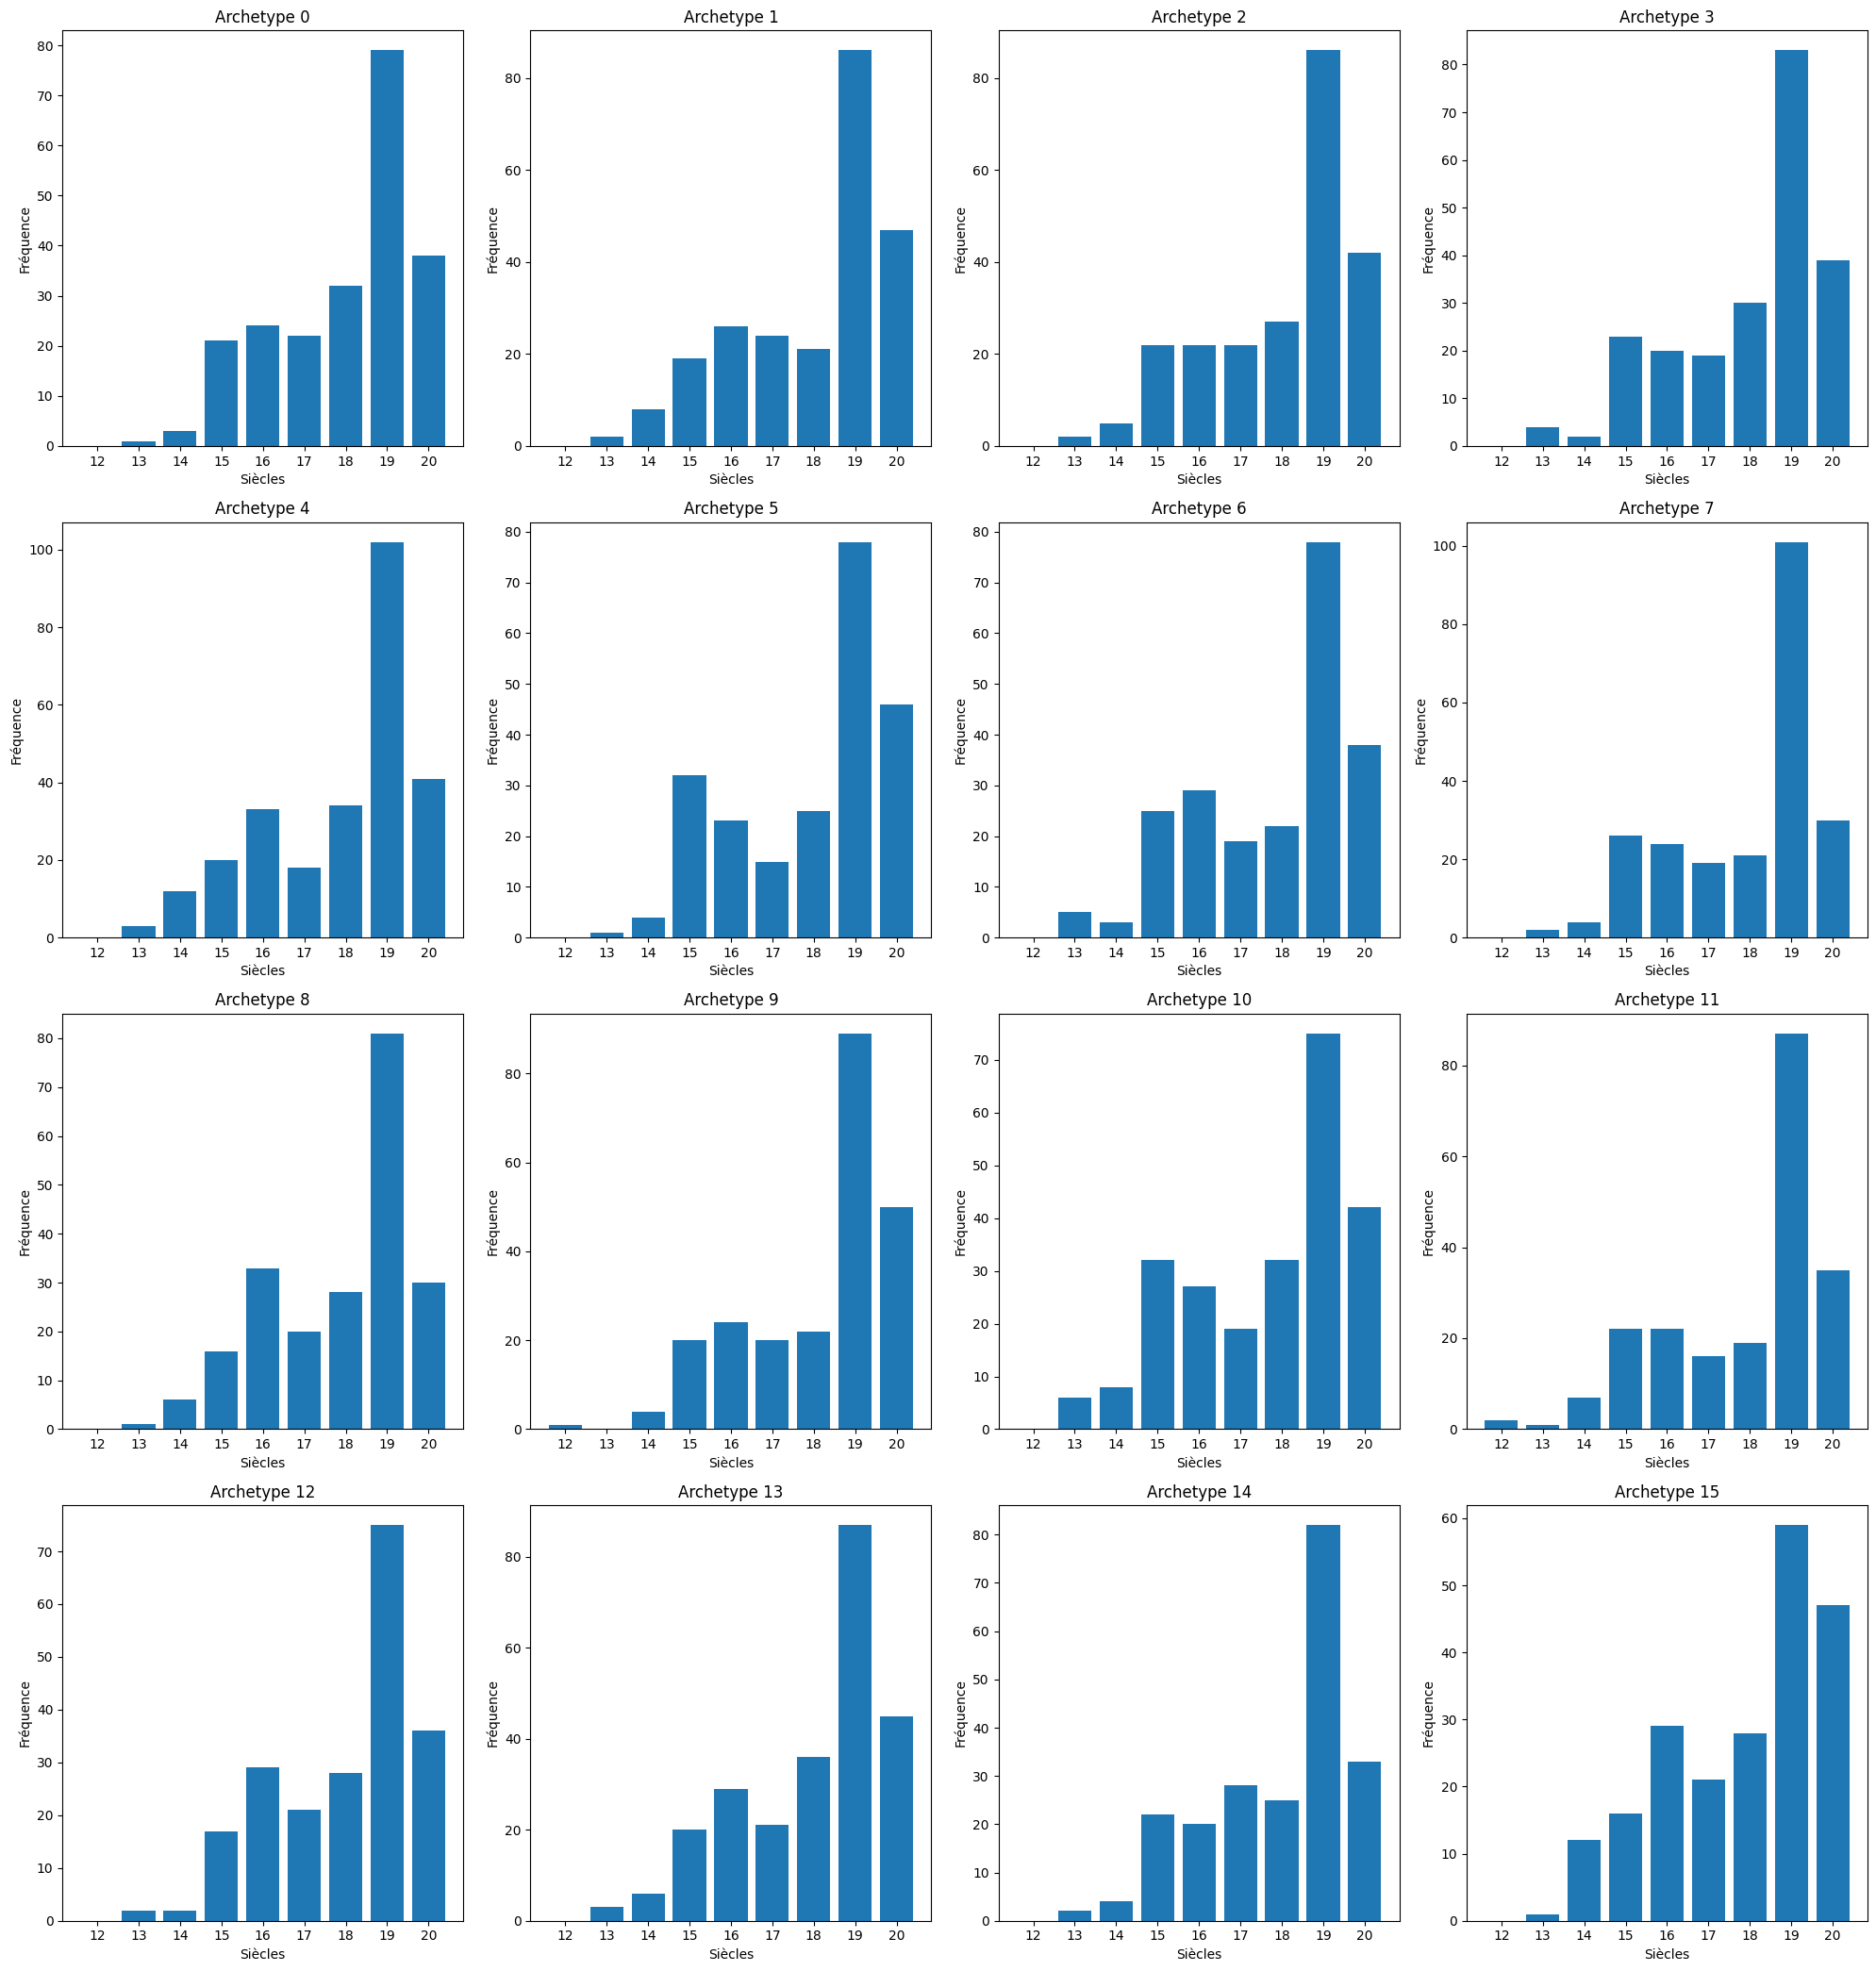

In [54]:
import re

def extract_year(path):
    match = re.search(r'_(\d{3,4})', path)
    if match :
        return int(match.group(1)) 
    else:
        match = re.search(r'-(\d{3,4})', path)
        return int(match.group(1)) 
    
def year_to_century(path):
    year = extract_year(path)
    return (year - 1) // 100 + 1
inds = [i for i in range(12, 21)]

distrib = []
cols = 4
rows = (n_archetype + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows+5))
axes = axes.flatten()
for i in range(n_archetype):
    siecles_i = {}
    L = a.getPaintingsFromArchetype(i)
    for k in range(len(L)):
        century=year_to_century(L[k])
        if century not in siecles_i.keys():
            siecles_i[century]=1
        else:
            siecles_i[century]+=1
    values = [siecles_i.get(k, 0) for k in inds]
    distrib.append(values)
    print(f"{len(values)}:{values}")
    ax = axes[i]
    ax.bar(inds, values, width=0.8)
    ax.set_xticks(inds)
    ax.set_xlabel("Siècles")
    ax.set_ylabel("Fréquence")
    ax.set_title(f"Archetype {i}")
plt.tight_layout()
plt.show()
        



3639


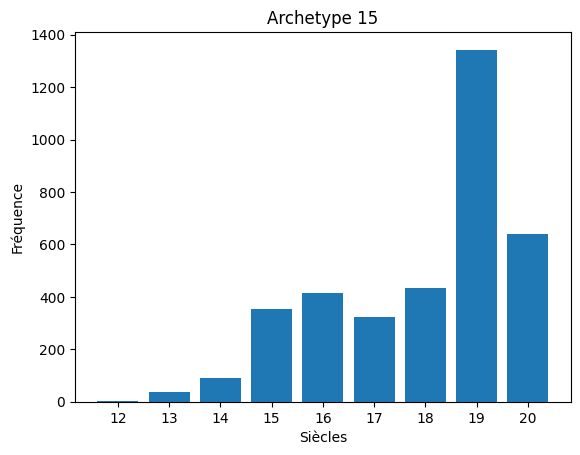

In [53]:
L = paths
print(len(L))
siecles = {}
for k in range(len(L)):
        century=year_to_century(L[k])
        if century not in siecles.keys():
            siecles[century]=1
        else:
            siecles[century]+=1
keys = sorted(siecles.keys())
values = [siecles.get(k, 0) for k in keys]
plt.bar(keys, values, width=0.8)
plt.xticks(keys)
plt.xlabel("Siècles")
plt.ylabel("Fréquence")
plt.title(f"Archetype {i}")
plt.show()
